# Esplorazione — Hotel Revenue Analytics

Notebook di esplorazione rapida della pipeline di analisi. **Non sostituisce gli script in `scripts/`**, che restano la fonte di verità per i numeri e i grafici del [report finale](../report.md) — questo notebook li affianca per rendere il progetto leggibile in pochi minuti, ad esempio a chi lo valuta per la prima volta.

Usa i CSV già prodotti dagli script in `data/` (non rigenera il dataset né rifà da zero i passaggi più pesanti), quindi è veloce da eseguire da cima a fondo.

Passaggi coperti: caricamento dati puliti → RevPAR/ADR → segmentazione ospiti → modello di ritorno ospite → test causale sull'effetto della promo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option("display.max_columns", 50)

RNG_SEED = 42

# palette coerente con i grafici in charts/ (vedi scripts/step2_revpar_seasonality.py)
COL_1 = "#2a78d6"      # blu
COL_2 = "#1baf7a"      # verde acqua
COL_NAIVE = "#eb6834"  # arancio - stima non corretta / da evidenziare
COL_MUTED = "#898781"
COL_GRID = "#e1e0d9"

plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["axes.edgecolor"] = COL_MUTED

## 1. Caricamento dati puliti

`data/bookings_clean.csv` è l'output di `scripts/clean_and_merge.py`: prenotazioni con nomi normalizzati per il join cross-fonte, valuta convertita in EUR, date validate e i flag usati a valle della pipeline (`high_season`, `post_promo`, `nome_ambiguo`).

In [2]:
bookings = pd.read_csv("../data/bookings_clean.csv", parse_dates=["check_in", "check_out"])

print(f"{len(bookings)} prenotazioni | {bookings['guest_name_norm'].nunique()} nomi ospite distinti")
print(f"Cancellate: {bookings['cancelled'].mean():.1%} | Nome ambiguo: {bookings['nome_ambiguo'].mean():.1%}")

bookings.head()

3808 prenotazioni | 3053 nomi ospite distinti
Cancellate: 9.0% | Nome ambiguo: 14.7%


,booking_id,guest_name_norm,email,country,cibo_preferito,prima_visita,check_in,check_out,nights,channel,currency,room_rate,room_rate_eur,cancelled,net_revenue_eur,high_season,post_promo,date_corretta,nome_ambiguo
0,BK00000,nilsson sophie,sophie.nilsson169@gmail.com,Spain,pesce,2024-09-10,2024-09-10,2024-09-14,4,OTA,EUR,385.71,385.71,False,1542.84,True,False,False,False
1,BK00001,silva thomas,thomas.silva434@gmail.com,Italy,pesce,2024-09-10,2024-09-10,2024-09-13,3,OTA,EUR,441.31,441.31,True,0.00,True,False,False,False
2,BK00002,chiara meyer,chiara.meyer316@outlook.com,Germany,internazionale,2024-09-10,2024-09-10,2024-09-13,3,OTA,EUR,380.37,380.37,False,1141.11,True,False,False,False
3,BK00003,schmidt simone,simone.schmidt639@outlook.com,Japan,internazionale,2024-09-10,2024-09-10,2024-09-15,5,OTA,EUR,475.99,475.99,False,2379.95,True,False,False,False
4,BK00004,al-rashid francesco,francesco.al-rashid399@icloud.com,Japan,kosher,2024-09-10,2024-09-10,2024-09-14,4,direct,EUR,412.62,412.62,False,1650.48,True,False,False,True


## 2. RevPAR / ADR mensile

`data/monthly_revpar_adr.csv` è l'aggregato mensile già calcolato da `scripts/step2_revpar_seasonality.py` (espansione a room-night, ADR = ricavo/notti occupate, RevPAR = ricavo/notti disponibili). Qui lo carico e basta, senza rifare l'espansione riga per riga.

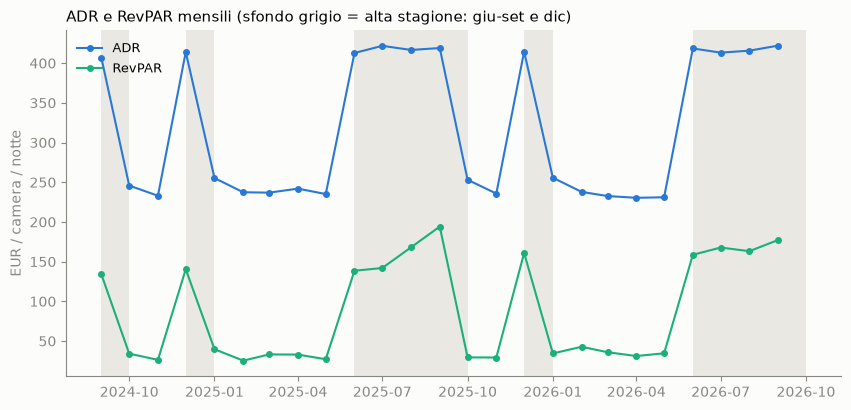

RevPAR medio alta stagione: 158.6 EUR
RevPAR medio bassa stagione: 32.5 EUR


In [3]:
monthly = pd.read_csv("../data/monthly_revpar_adr.csv", parse_dates=["month"])

fig, ax = plt.subplots(figsize=(10, 4.5))

for _, row in monthly.iterrows():
    if row["alta_stagione"]:
        m0 = row["month"]
        m1 = m0 + pd.offsets.MonthBegin(1)
        ax.axvspan(m0, m1, color=COL_GRID, alpha=0.7, lw=0)

ax.plot(monthly["month"], monthly["ADR"], color=COL_1, marker="o", markersize=4, label="ADR")
ax.plot(monthly["month"], monthly["RevPAR"], color=COL_2, marker="o", markersize=4, label="RevPAR")
ax.set_title("ADR e RevPAR mensili (sfondo grigio = alta stagione: giu-set e dic)", loc="left", fontsize=11)
ax.set_ylabel("EUR / camera / notte", color=COL_MUTED)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=COL_MUTED)
plt.show()

print(f"RevPAR medio alta stagione: {monthly.loc[monthly.alta_stagione, 'RevPAR'].mean():.1f} EUR")
print(f"RevPAR medio bassa stagione: {monthly.loc[~monthly.alta_stagione, 'RevPAR'].mean():.1f} EUR")

## 3. Segmentazione ospiti (one-time vs repeat)

`data/guest_segments.csv` è l'output di `scripts/step3_repeat_guest_model.py`: una riga per ospite (nome non ambiguo), con gli attributi della prima visita e il target `repeat` (tornato entro 18 mesi, con correzione per censura sugli ospiti la cui finestra di osservazione non è ancora completa — vedi lo script per i dettagli).

In [4]:
guests = pd.read_csv("../data/guest_segments.csv", parse_dates=["prima_visita_effettiva"])

tasso = guests["repeat"].mean()
print(f"Ospiti analizzati: {len(guests)} | Tasso di ritorno entro 18 mesi: {tasso:.1%} "
      f"({guests['repeat'].sum()} repeat)")

print("\nTasso di ritorno per canale della prima prenotazione:")
print(guests.groupby("canale_prima_visita")["repeat"].mean().round(3))

print("\nTasso di ritorno per stagione della prima visita:")
print(guests.groupby("alta_stagione_prima_visita")["repeat"].mean().round(3))

Ospiti analizzati: 588 | Tasso di ritorno entro 18 mesi: 25.3% (149 repeat)

Tasso di ritorno per canale della prima prenotazione:
canale_prima_visita
OTA       0.216
direct    0.341
Name: repeat, dtype: float64

Tasso di ritorno per stagione della prima visita:
alta_stagione_prima_visita
False    0.207
True     0.307
Name: repeat, dtype: float64


## 4. Modello di previsione del ritorno ospite

Stesse feature e stesso split di `scripts/step3_repeat_guest_model.py` (Logistic Regression vs Random Forest), riallenati qui su `guest_segments.csv` — il dataset è piccolo (588 ospiti) quindi il training è quasi istantaneo, non serve salvare risultati intermedi.

Spoiler: l'AUC è debole (0,49-0,54). Il perché — e cosa proverei dopo — è discusso in dettaglio nella sezione *"Perché l'AUC è debole e cosa proverei dopo"* del [report finale](../report.md): in sintesi, il tetto è nei dati disponibili (segnale intrinsecamente piccolo, campione modesto), non nella scelta tra i due modelli.

In [5]:
feat_num = ["adr_prima_visita", "durata_prima_visita"]
feat_cat = ["canale_prima_visita", "alta_stagione_prima_visita", "paese"]

X = pd.get_dummies(guests[feat_num + feat_cat], columns=feat_cat, drop_first=False)
y = guests["repeat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RNG_SEED, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RNG_SEED)
logreg.fit(X_train_s, y_train)
proba_lr = logreg.predict_proba(X_test_s)[:, 1]

rf = RandomForestClassifier(
    n_estimators=400, max_depth=5, min_samples_leaf=5,
    class_weight="balanced", random_state=RNG_SEED,
)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Train: {len(X_train)} ospiti ({y_train.mean():.1%} repeat) | Test: {len(X_test)} ospiti ({y_test.mean():.1%} repeat)")
print(f"\nAUC Logistic Regression: {roc_auc_score(y_test, proba_lr):.3f}")
print(f"AUC Random Forest:       {roc_auc_score(y_test, proba_rf):.3f}")

Train: 441 ospiti (25.4% repeat) | Test: 147 ospiti (25.2% repeat)

AUC Logistic Regression: 0.486
AUC Random Forest:       0.536


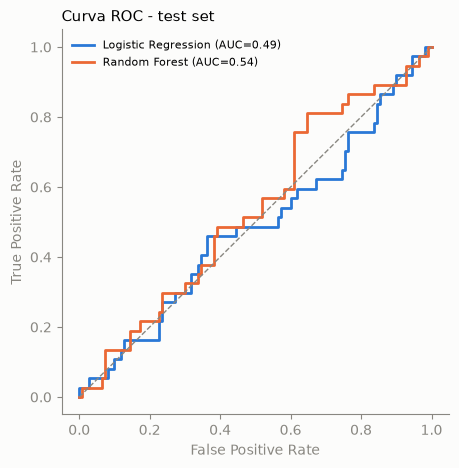

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

for name, proba, color in [
    ("Logistic Regression", proba_lr, COL_1), ("Random Forest", proba_rf, COL_NAIVE)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, proba):.2f})")

ax.plot([0, 1], [0, 1], color=COL_MUTED, lw=1, ls="--")
ax.set_xlabel("False Positive Rate", color=COL_MUTED)
ax.set_ylabel("True Positive Rate", color=COL_MUTED)
ax.set_title("Curva ROC - test set", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=COL_MUTED)
plt.show()

## 5. Test causale: effetto della promo booking diretto (paradosso di Simpson)

`bookings_clean.csv` contiene già `post_promo` (prenotazione prima/dopo il lancio della promo) e `high_season`. Il confronto grezzo pre/post promo confonde l'effetto della promo con il mix stagionale, perché la finestra "post" (ultimi 6 mesi) contiene strutturalmente più mesi di alta stagione della finestra "pre" (18 mesi) — e l'alta stagione da sola genera più booking diretti a prescindere dalla promo. Qui replico il confronto aggregato, quello segmentato per stagione, e la regressione logistica di controllo di `scripts/step4_promo_test.py`.

In [7]:
df = bookings.copy()
df["post_promo"] = df["post_promo"].astype(bool)
df["high_season"] = df["high_season"].astype(bool)
df["direct"] = (df["channel"] == "direct").astype(int)


def direct_share_diff(sub: pd.DataFrame) -> float:
    ct = pd.crosstab(sub["post_promo"], sub["channel"], normalize="index")
    return (ct.loc[True, "direct"] - ct.loc[False, "direct"]) * 100


agg_diff = direct_share_diff(df)
high_diff = direct_share_diff(df[df.high_season])
low_diff = direct_share_diff(df[~df.high_season])

model = smf.logit("direct ~ post_promo + high_season", data=df).fit(disp=0)
mfx = model.get_margeff(at="overall")
reg_diff = mfx.margeff[0] * 100
p_value = model.pvalues["post_promo[T.True]"]

mix = df.groupby("post_promo")["high_season"].mean()
print("Il confondente - quota di prenotazioni in alta stagione:")
print(f"  Pre-promo:  {mix.loc[False]:.1%}")
print(f"  Post-promo: {mix.loc[True]:.1%}\n")

print(f"Aggregato (NON controllato per stagione): {agg_diff:+.1f} pp")
print(f"Alta stagione, pre vs post:                {high_diff:+.1f} pp")
print(f"Bassa stagione, pre vs post:                {low_diff:+.1f} pp")
print(f"Regressione logistica (controllato):        {reg_diff:+.1f} pp  (p={p_value:.4f})")

Il confondente - quota di prenotazioni in alta stagione:
  Pre-promo:  54.4%
  Post-promo: 69.9%

Aggregato (NON controllato per stagione): +9.1 pp
Alta stagione, pre vs post:                +5.8 pp
Bassa stagione, pre vs post:                +6.3 pp
Regressione logistica (controllato):        +5.7 pp  (p=0.0006)


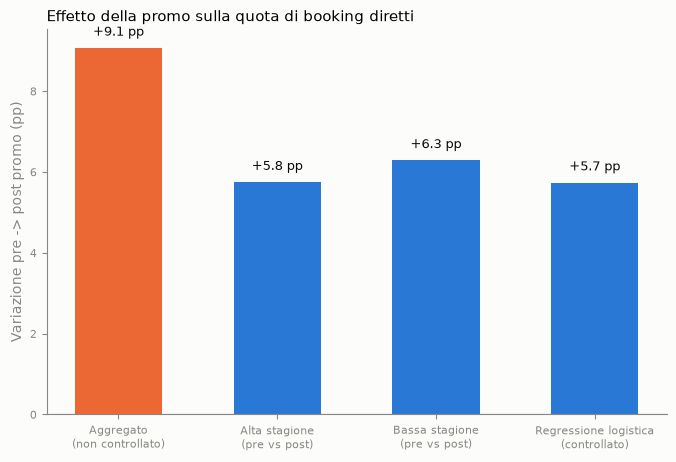

In [8]:
labels = [
    "Aggregato\n(non controllato)", "Alta stagione\n(pre vs post)",
    "Bassa stagione\n(pre vs post)", "Regressione logistica\n(controllato)",
]
values = [agg_diff, high_diff, low_diff, reg_diff]
colors = [COL_NAIVE, COL_1, COL_1, COL_1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, values, color=colors, width=0.55)
for i, v in enumerate(values):
    ax.text(i, v + 0.3, f"+{v:.1f} pp", ha="center", fontsize=9, color="#0b0b0b")

ax.axhline(0, color=COL_MUTED, lw=0.8)
ax.set_title("Effetto della promo sulla quota di booking diretti", loc="left", fontsize=11)
ax.set_ylabel("Variazione pre -> post promo (pp)", color=COL_MUTED)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=COL_MUTED, labelsize=8)
plt.show()

## Conclusioni

I numeri qui riprodotti coincidono con quelli discussi nel [report finale](../report.md): stagionalità come driver dominante dei ricavi, effetto reale della promo più modesto (~+5,7 pp) di quanto suggerisca il confronto grezzo (~+9 pp), e un modello di ritorno ospite onestamente debole (AUC 0,49-0,54) dato il segnale disponibile nella prima visita.

Per l'analisi completa, i grafici in alta risoluzione e le raccomandazioni operative, vedi `report.md`; per la pipeline completa e riproducibile passo per passo, vedi gli script in `scripts/`.